# Dataset e preprocessing

In [147]:
# Carica le librerie
import torch

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Autoencoder
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers


from sklearn.preprocessing import MinMaxScaler # per normalizzare in [0,1] le colonne a valori continui

# Isolation forest
from sklearn.ensemble import IsolationForest
import shap


In [2]:
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# dataset delle red flag per ogni stazione appaltante
X_raw = pd.read_csv("red_flag_stazioni_2011_2025.csv")


In [ ]:
# Poiché sembrano avere caratteristiche diverse dal resto delle stazioni appaltanti,
# dividiamo l'analisi in 3 Tipologie: comuni/scuole/altro

# per dividere tra comuni/scuole, poiché non sono presenti colonne esaustive nei dati originali,
# è necessario cercare tramite il nome, il quale tranne in rari casi è consistente nel formato,
# il che rende buona l'individuazione delle dummy

dummy_comuni = X_raw["denominazione"].str.contains(r"^COMUNE\b", case=False, na=False)
dummy_scuole = X_raw["denominazione"].str.contains(
        r"\b(LICEO|ISTITUTO D'ISTRUZIONE|ISTITUTO TECNICO|ISTITUTO PROFESSIONALE|ISTITUTO SCOLASTICO|ISTITUTO COMPRENSIVO|ISTITUTO OMNICOMPRENSIVO|I\.T\.T\.S|ISTITUTO ISTRUZIONE|SCUOLA)\b",
        case=False,
        na=False
    )
dummy_else = (dummy_comuni == False) & (dummy_scuole == False)

X_raw_comuni = X_raw[dummy_comuni].reset_index(drop = True)
X_raw_scuole = X_raw[dummy_scuole].reset_index(drop = True)
X_raw_else = X_raw[dummy_else].reset_index(drop = True)

print(f"{sum(dummy_comuni)} Comuni su {dummy_comuni.shape[0]} Stazioni totali")
print(f"{sum(dummy_scuole)} Scuole su {dummy_scuole.shape[0]} Stazioni totali")
print(f"{sum(dummy_else)} altre stazioni su {dummy_else.shape[0]} Stazioni totali")

8036 Comuni su 33653 Stazioni totali
8136 Scuole su 33653 Stazioni totali
17481 altre stazioni su 33653 Stazioni totali


C:\Users\dakot\AppData\Local\Temp\ipykernel_6252\3066661012.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dummy_scuole = X_raw["denominazione"].str.contains(


In [ ]:
# scelta dei dati su cui svolgere l'analisi
tipologia = "altro"  # opzioni: "scuole", "comuni", "tutto", "altro"

if tipologia == "scuole":
    X_chosen = X_raw_scuole.copy()
elif tipologia == "comuni":
    X_chosen = X_raw_comuni.copy()
elif tipologia == "tutto":  # sconsigliato, ma offre una visione d'insieme
    X_chosen = X_raw.copy()
    X_chosen["is_comune"] = dummy_comuni * 1
    X_chosen["is_scuola"] = dummy_scuole * 1
elif tipologia == "altro":
    X_chosen = X_raw_else.copy()
else:
    raise ValueError(f"Tipo dataset non valido: {tipologia}")


# normalizzazione delle colonne, in [0,1]
def normalize_cols(X, cols_to_normalize):
    # invece di usare min max, evito di considerare gli outlier enormi nel min maxing
    lower = X[cols_to_normalize].quantile(0.01)
    upper = X[cols_to_normalize].quantile(0.99)
    X[cols_to_normalize] = X[cols_to_normalize].clip(lower, upper, axis=1)

    # scaler = StandardScaler()
    scaler = MinMaxScaler()
    # standardizza le colonne con valori continui
    X[cols_to_normalize] = scaler.fit_transform(X[cols_to_normalize])

    return X


cols_to_normalize = [
    "num_appalti","num_appalti_diretti","val_tot",
    "mean_diff_date1","mean_diff_date2",
    "scostamento_costi",
    "prop_contr_stessa_azienda","prop_offerte_escluse",
    "prop_na_importo_gara","calcolabile_tot"
]



X_full = normalize_cols(X_chosen.copy(), cols_to_normalize)

# Rimuovo le colonne di CF_stazione e denominazione per l'analisi
X = X_full.drop(["CF_stazione","denominazione"], axis = 1)
X

,num_appalti,num_appalti_diretti,val_tot,prop_na_criterio_aggiudicazione,prop_na_offerte_ammesse,prop_na_importo_gara,prop_date_contrarie,offerta_econo_vant,val_proc_non_aperte,contr_almeno_una_var,scostamento_costi,inademp_comun_aggiudicazione,offerta_singola,prop_offerte_escluse,escl_tutte_tranne_una,prop_contr_stessa_azienda,mean_diff_date1,mean_diff_date2,calcolabile_tot
0,0.024322,0.000000,0.083683,0.617284,1.000000,0.0,0.428571,0.000000,0.015026,0.000000,0.465196,0.477366,0.000000,0.000000,0.000000,0.044353,0.000000,0.708677,0.4
1,0.003129,0.336735,0.000196,0.000000,1.000000,0.0,0.121212,0.000000,1.000000,0.000000,0.465196,0.000000,0.000000,0.000000,0.000000,0.044353,0.167373,0.732621,0.3
2,0.000606,0.040816,0.001549,0.375000,0.875000,0.0,0.000000,0.000000,0.942369,0.000000,0.465196,0.250000,0.000000,0.000000,0.000000,0.033939,0.231746,0.743114,0.6
3,0.029772,0.000000,0.065967,0.053872,0.424242,0.0,0.057143,0.177936,0.115007,0.067416,0.472334,0.047138,0.666667,0.033117,0.017241,0.008154,0.247646,0.759726,1.0
4,0.000706,0.000000,0.001653,0.888889,0.888889,0.0,0.000000,0.000000,0.079582,0.000000,0.465196,0.777778,1.000000,0.000000,0.000000,0.044353,0.320882,0.736376,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17476,0.000000,0.000000,0.000244,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.465196,1.000000,0.000000,0.000000,0.000000,0.044353,0.344443,0.736956,0.1
17477,0.034314,1.000000,0.000849,1.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.465196,1.000000,0.000000,0.000000,0.000000,0.044353,0.176893,0.736956,0.1
17478,0.000101,0.010204,0.000186,1.000000,1.000000,0.0,0.000000,0.000000,0.587060,0.000000,0.465196,1.000000,0.000000,0.000000,0.000000,0.044353,0.370041,0.736956,0.1
17479,0.000807,0.091837,0.000291,0.500000,0.500000,0.0,0.000000,0.000000,1.000000,0.000000,0.465196,0.100000,0.800000,0.145028,0.000000,0.046929,0.211800,0.731564,0.7


# Autoencoder

### Modello

In [ ]:
# modello dell'autoencoder
def autoencoder_model(layers_dimensions):

    input_layer = keras.Input(shape=(layers_dimensions[0],))

    # Encoder
    encoded = layers.Dense(layers_dimensions[1], 
                        activation="leaky_relu", 
                        activity_regularizer=keras.regularizers.l2(1e-5))(input_layer)

    encoded = layers.Dropout(0.05)(encoded)

    encoded = layers.Dense(layers_dimensions[2], 
                            activation="leaky_relu", 
                            kernel_regularizer=keras.regularizers.l2(1e-5))(encoded)

    # Bottleneck
    bottleneck = layers.Dense(layers_dimensions[3], 
                            activation="leaky_relu",
                            kernel_regularizer=keras.regularizers.l1(1e-5)
                            )(encoded)

    # Decoder
    decoded = layers.Dense(layers_dimensions[2], activation="leaky_relu")(bottleneck)
    
    decoded = layers.Dense(layers_dimensions[1], activation="leaky_relu")(decoded)
    output_layer = layers.Dense(layers_dimensions[0], activation="sigmoid")(decoded)

    autoencoder = keras.Model(inputs=input_layer, outputs=output_layer)

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss="mse"
    )

    return autoencoder

In [9]:
# early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


### Training ed evaluation


In [ ]:
# dimensione dell'input (e output)
input_dim = X.shape[1]

layers_dimensions = [input_dim, 18, 12, 6]

# numero di volte che verrà ripetuta l'analisi con l'autoencoder
rounds = 10 # (meno di 1 min a round)

# liste placeholder 
CF_list = X_full["CF_stazione"]

all_scores = {cf: [] for cf in CF_list}
all_recon_errors = {cf: [] for cf in CF_list}
models = []

for r in range(1, rounds + 1):
    print(f"Starting round {r}")
    # train model
    autoencoder = autoencoder_model(layers_dimensions)

    autoencoder.fit(
        X, X,
        epochs=200,
        batch_size=128,
        validation_data=(X, X),  # same dataset
        callbacks=[early_stop],
        verbose=0
    )

    # reconstruction error (on full data)
    reconstructions = autoencoder.predict(X, verbose=0)
    reconstruction_errors = (X.values - reconstructions) ** 2
    anomaly_score = reconstruction_errors.mean(axis=1)

    # store model
    models.append(autoencoder)
    # store CF-level info
    for i, cf in enumerate(CF_list):
        all_scores[cf].append(anomaly_score[i])
        all_recon_errors[cf].append(reconstruction_errors[i])
print("Finished")



Starting round 1
Starting round 2
Starting round 3
Starting round 4
Starting round 5
Starting round 6
Starting round 7
Starting round 8
Starting round 9
Starting round 10
Finished


In [45]:
# organizzazione del dataaset risultante

# df degli anomaly score per ogni round
all_scores_df = pd.DataFrame(all_scores).T.reset_index(names = "CF_stazione")

# stesso dataset ma con il rank in ogni round per ogni stazione
ranked = all_scores_df.set_index("CF_stazione").rank(ascending=False, method="min")

ranked["denominazione"] = X_chosen["denominazione"].to_list()
all_scores_df["denominazione"] = X_chosen["denominazione"].to_list()

# ranked

In [46]:
rounds_cols = list(all_scores_df.drop(["CF_stazione","denominazione"], axis = 1))

# rimuovere il primo e ultimo rank prima di fare la media
ranked["mean_rank_trimmed"] = (
    ranked[rounds_cols].sum(axis=1)
    - ranked[rounds_cols].max(axis=1)
    - ranked[rounds_cols].min(axis=1)
) / (len(rounds_cols) - 2)

# ranking risultante
final_ranking = ranked.sort_values(by="mean_rank_trimmed").reset_index()
# final_ranking # non mostrato per privacy

In [27]:
final_ranking.to_csv("final_ranking.csv", index = False)

## Analisi d'insieme

In [ ]:
# mostra quanto sono correlati tra loro i risultati dei vari round
corr = ranked[rounds_cols].corr(method="spearman")
corr

# ~0.9, abbastanza correlazione da non rischiare overfitting, ma abbastanza da avere risultati robusti in media


,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.911362,0.882923,0.876943,0.942367,0.948343,0.916093,0.887164,0.922892,0.898353
1,0.911362,1.000000,0.884660,0.887974,0.914050,0.917056,0.896429,0.881772,0.896481,0.903750
2,0.882923,0.884660,1.000000,0.899073,0.882883,0.883896,0.889628,0.906874,0.895075,0.905915
3,0.876943,0.887974,0.899073,1.000000,0.869354,0.873501,0.877225,0.879917,0.879302,0.926261
4,0.942367,0.914050,0.882883,0.869354,1.000000,0.941328,0.903019,0.890239,0.912308,0.890119
5,0.948343,0.917056,0.883896,0.873501,0.941328,1.000000,0.900512,0.890644,0.911069,0.894819
6,0.916093,0.896429,0.889628,0.877225,0.903019,0.900512,1.000000,0.881300,0.943127,0.901232
7,0.887164,0.881772,0.906874,0.879917,0.890239,0.890644,0.881300,1.000000,0.880240,0.904007
8,0.922892,0.896481,0.895075,0.879302,0.912308,0.911069,0.943127,0.880240,1.000000,0.900058
9,0.898353,0.903750,0.905915,0.926261,0.890119,0.894819,0.901232,0.904007,0.900058,1.000000


In [66]:
flags_names = list(X_chosen.drop(["CF_stazione","denominazione"], axis = 1))

# Colleziona tutti gli array
all_arrays = []
for round_errors in all_recon_errors.values():
    all_arrays.extend(round_errors)

# Stack e calcola la media per varaibile
stacked = np.stack(all_arrays)
mean_per_feature = np.mean(stacked, axis=0)
mean_per_feature

# Dataframe
mean_feature_df = pd.DataFrame({
    "feature": flags_names,
    "mean_reconstruction_error": mean_per_feature
})

# sort
mean_feature_df = mean_feature_df.sort_values(by="mean_reconstruction_error", ascending=False).reset_index(drop=True)

mean_feature_df
# variabili con recosntruction error maggiore in media

,feature,mean_reconstruction_error
0,scostamento_costi,0.008354
1,mean_diff_date2,0.008191
2,mean_diff_date1,0.005638
3,prop_date_contrarie,0.005513
4,offerta_econo_vant,0.005253
5,prop_na_importo_gara,0.004474
6,offerta_singola,0.003834
7,prop_offerte_escluse,0.003600
8,calcolabile_tot,0.003548
9,num_appalti_diretti,0.003492


## Analisi singola stazione

Nota: Molti degli output sono censurati per questioni di privacy, per runnare il codice basta togliere il commento dalle righe in questione


In [ ]:

CF_to_analyze = "abcdefghijk" # codice a caso



In [ ]:
# valori delle flag originali per la stazione scelta
# X_chosen[X_chosen["CF_stazione"] == CF_to_analyze]


In [50]:
# guardare i reconstruction errors per la stazione specificata per il round specificato
round_to_analyze = 0 # {0,1,...,9}

# pd.DataFrame(
#     all_recon_errors[CF_to_analyze][round_to_analyze],
#     columns = [CF_to_analyze],
#     index=flags_names
# ).T



## SHAP autoencoder

In [51]:
import importlib
from ExplainSHAP import ExplainSHAP

In [ ]:
# valori delle flag dopo la normalizzazione
# X_full[X_full["CF_stazione"] == CF_to_analyze]



In [ ]:
# run SHAP per ogni round per la stazione scelta
def SHAP_explaination(CF_to_analyze):
    SHAP_results = []

    X_full_to_analyze = X_full[X_full["CF_stazione"] == CF_to_analyze]

    for r in rounds_cols:
        
        model = models[r]
        
        exp_model = ExplainSHAP(num_anomalies_to_explain=1, 
                                reconstruction_error_percent = 0.5,
                                autoencoder= model
                                )
        all_sets_explaining_features = exp_model.explain_data(x_train=X, 
                                                            x_explain=X_full_to_analyze.drop(["CF_stazione","denominazione"], axis = 1),
                                                            top_k = 3
                                                            )
        # print(all_sets_explaining_features)
        
        SHAP_results.append(all_sets_explaining_features)
    return SHAP_results

SHAP_results = SHAP_explaination(CF_to_analyze)
# SHAP_results


Variabili processate: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]


## Isolation forest

In [145]:
IF_model = IsolationForest(
    n_estimators=300,        # numero alberi # 300-500 tunable
    contamination=0.05,      # % anomalie attese
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

In [148]:
IF_model.fit(X)

c:\Users\dakot\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


IsolationForest(contamination=0.05, n_estimators=300, n_jobs=-1,
                random_state=42)

In [149]:
# anomaly score
scores = IF_model.decision_function(X)
labels = IF_model.predict(X)

In [ ]:
IF_anomaly_scores = pd.DataFrame({
    "CF_stazione": X_full["CF_stazione"],
    "denominazione": X_full["denominazione"],

    "anomaly_score": scores,
    "anomaly_label": labels
})

IF_results = pd.concat(
    [IF_anomaly_scores.reset_index(drop=True), X.reset_index(drop=True)],
    axis=1
)
IF_X_full_index = IF_anomaly_scores.reset_index(names = "X_full_index")

# IF_results

## SHAP Isolation Forest

In [158]:
explainer = shap.TreeExplainer(IF_model)
shap_values = explainer.shap_values(X)


C:\Users\dakot\AppData\Local\Temp\ipykernel_6252\2769818484.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


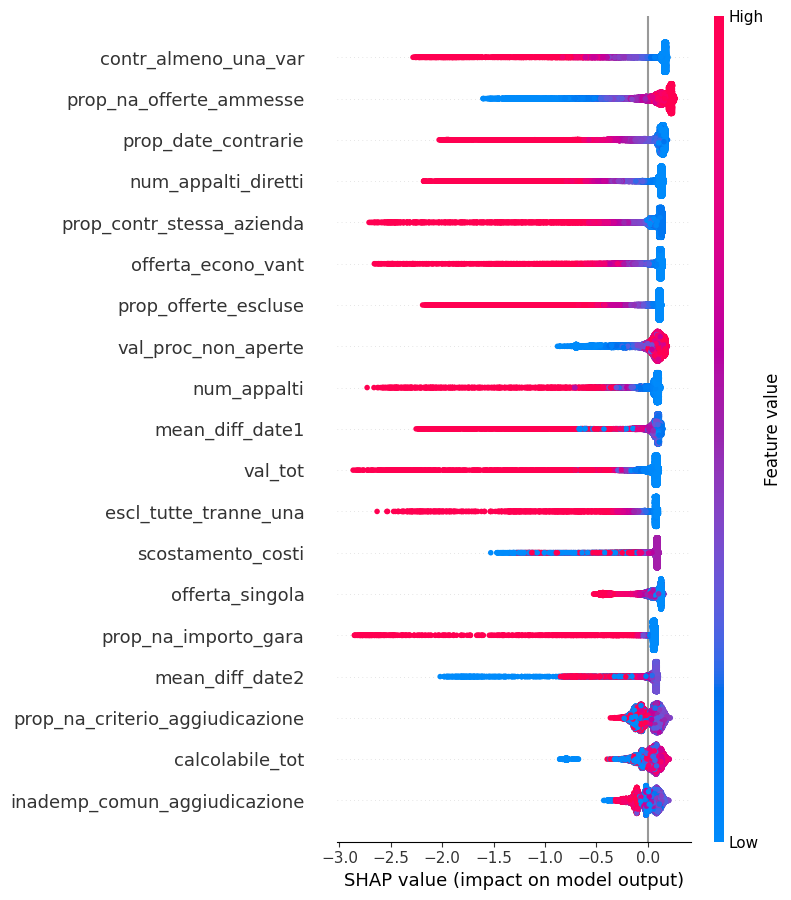

In [159]:
shap.summary_plot(shap_values, X)
# le variabili sono ordinate per importanza nel rilevare le anomalie
# più a sinistra tende, più è anomala
# se il colore della parte destra è rosso = High, significa che valori alti di quella variabile causano anomalie
# più in alto una varaibile, più è rilevante il suo valore e ha una divisione più netta tra valori anomali e non

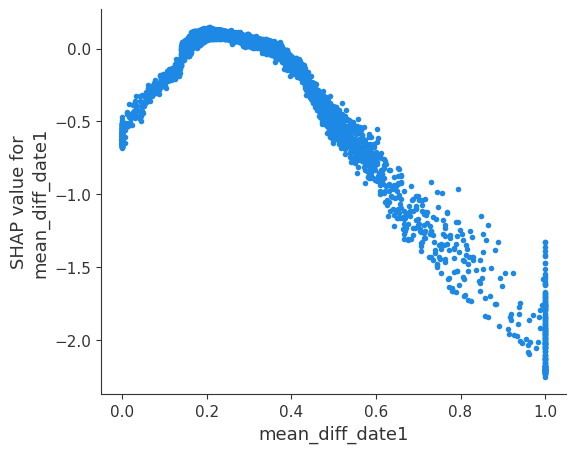

In [ ]:
shap.dependence_plot("mean_diff_date1",shap_values, X, interaction_index = None)


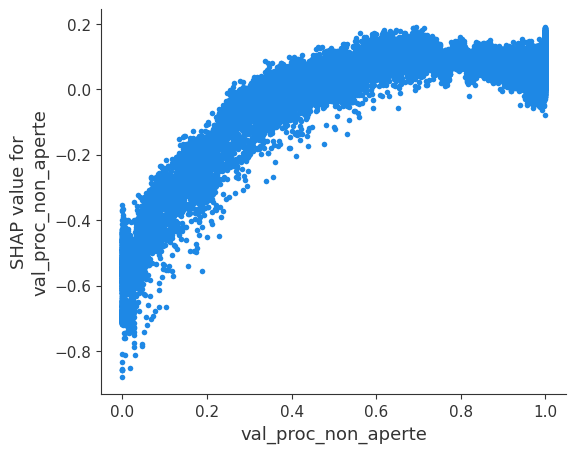

In [163]:
shap.dependence_plot("val_proc_non_aperte",shap_values, X, interaction_index = None)


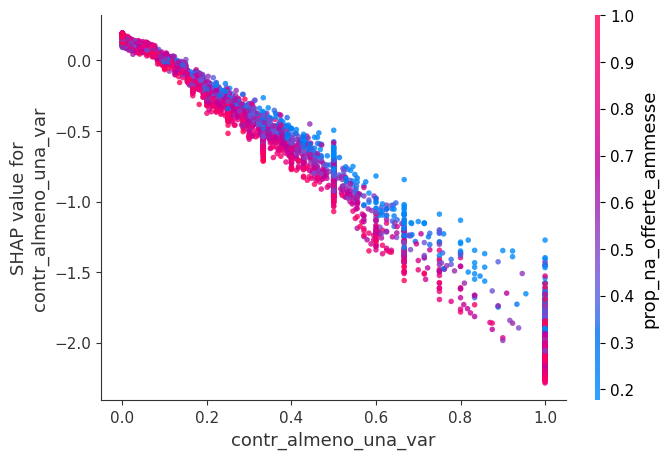

In [164]:
# shap.dependence_plot("val_proc_non_aperte",shap_values, X, interaction_index = 18)
shap.dependence_plot("contr_almeno_una_var",shap_values, X, interaction_index = 4, alpha = 0.8)


In [ ]:

# AE_index_to_analyze = final_ranking[final_ranking["CF_stazione"] == CF_to_analyze].index[0] # indice del CF_to_analyze nell'autoencoder


In [172]:

# top_cases = IF_results.reset_index(names = "X_full_index")

def IF_explain_score(CF_to_analyze):
    IF_index_to_analyze = IF_X_full_index[IF_X_full_index["CF_stazione"] == CF_to_analyze].index[0] # indice del CF_to_analyze nell'albero
    AE_index_to_analyze = final_ranking[final_ranking["CF_stazione"] == CF_to_analyze].index[0] # indice del CF_to_analyze nell'autoencoder
    index = IF_X_full_index[IF_X_full_index["CF_stazione"] == CF_to_analyze]

    index = index["X_full_index"].item()

    print(f"position in the Isolation Forest: {IF_index_to_analyze +1}")
    print(f"position in the Autoencoder: {AE_index_to_analyze +1}")


    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[index],
            base_values=explainer.expected_value,
            data=X.iloc[index],
            feature_names=X.columns
        )
    )
    # più una variabile è negativa, più ha spinto il risultato verso l'essere considerato un'anomalia
# IF_explain_score(CF_to_analyze)